## Extracción del Archivo Tratado

In [1]:
import pandas as pd

# Ruta del archivo limpio
ruta_archivo = "/content/TelecomX_LATAM.csv"

# Cargar el CSV
df = pd.read_csv(ruta_archivo)

In [3]:
df.head()


,customerID,Churn,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,...,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Cuentas_Diarias,Churn_binario
0,0002-ORFBO,No,Female,0,1,1,9,1,No,DSL,...,Yes,Yes,No,One year,1,Mailed check,65.6,593.30,2.19,0
1,0003-MKNFE,No,Male,0,0,0,9,1,Yes,DSL,...,No,No,Yes,Month-to-month,0,Mailed check,59.9,542.40,2.00,0
2,0004-TLHLJ,Yes,Male,0,0,0,4,1,No,Fiber optic,...,No,No,No,Month-to-month,1,Electronic check,73.9,280.85,2.46,1
3,0011-IGKFF,Yes,Male,1,1,0,13,1,No,Fiber optic,...,No,Yes,Yes,Month-to-month,1,Electronic check,98.0,1237.85,3.27,1
4,0013-EXCHZ,Yes,Female,1,1,0,3,1,No,Fiber optic,...,Yes,Yes,No,Month-to-month,1,Mailed check,83.9,267.40,2.80,1


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7032 non-null   object 
 1   Churn             7032 non-null   object 
 2   gender            7032 non-null   object 
 3   SeniorCitizen     7032 non-null   int64  
 4   Partner           7032 non-null   int64  
 5   Dependents        7032 non-null   int64  
 6   tenure            7032 non-null   int64  
 7   PhoneService      7032 non-null   int64  
 8   MultipleLines     7032 non-null   object 
 9   InternetService   7032 non-null   object 
 10  OnlineSecurity    7032 non-null   object 
 11  OnlineBackup      7032 non-null   object 
 12  DeviceProtection  7032 non-null   object 
 13  TechSupport       7032 non-null   object 
 14  StreamingTV       7032 non-null   object 
 15  StreamingMovies   7032 non-null   object 
 16  Contract          7032 non-null   object 


In [5]:
# Eliminar columnas irrelevantes
columnas_a_eliminar = ['customerID']
df = df.drop(columns=columnas_a_eliminar)

# Verificar que se eliminó
print("Columnas restantes:")
print(df.columns)

Columnas restantes:
Index(['Churn', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Cuentas_Diarias', 'Churn_binario'],
      dtype='object')


In [7]:
# Separar target y features
# Target: Churn_binario (ya la tienes)
y = df['Churn_binario']

# Features: eliminar Churn y Churn_binario para no incluirlas en encoding
X = df.drop(columns=['Churn', 'Churn_binario'])

In [8]:
# Identificar variables categóricas
categoricas = X.select_dtypes(include='object').columns.tolist()
print("Variables categóricas a codificar:", categoricas)

Variables categóricas a codificar: ['gender', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaymentMethod']


In [9]:
# Aplicar One-Hot Encoding
# One-Hot Encoding con get_dummies
X_encoded = pd.get_dummies(X, columns=categoricas, drop_first=True)

# Verificar el resultado
print("Shape antes:", X.shape)
print("Shape después del encoding:", X_encoded.shape)
X_encoded.head()

Shape antes: (7032, 20)
Shape después del encoding: (7032, 24)


,SeniorCitizen,Partner,Dependents,tenure,PhoneService,PaperlessBilling,MonthlyCharges,TotalCharges,Cuentas_Diarias,gender_Male,...,OnlineBackup_Yes,DeviceProtection_Yes,TechSupport_Yes,StreamingTV_Yes,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,1,9,1,1,65.6,593.30,2.19,False,...,True,False,True,True,False,True,False,False,False,True
1,0,0,0,9,1,0,59.9,542.40,2.00,True,...,False,False,False,False,True,False,False,False,False,True
2,0,0,0,4,1,1,73.9,280.85,2.46,True,...,False,True,False,False,False,False,False,False,True,False
3,1,1,0,13,1,1,98.0,1237.85,3.27,True,...,True,True,False,True,True,False,False,False,True,False
4,1,1,0,3,1,1,83.9,267.40,2.80,False,...,False,False,True,True,False,False,False,False,False,True


In [10]:
# Conteo de clientes activos y cancelados
conteo = df['Churn_binario'].value_counts()
print("Conteo de clases:\n", conteo)

Conteo de clases:
 Churn_binario
0    5163
1    1869
Name: count, dtype: int64


In [11]:
# Proporción
proporcion = df['Churn_binario'].value_counts(normalize=True)
print("\nProporción de cada clase:\n", proporcion)


Proporción de cada clase:
 Churn_binario
0    0.734215
1    0.265785
Name: proportion, dtype: float64


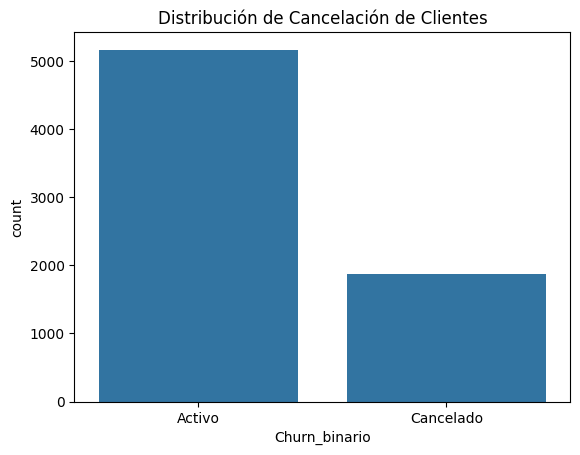

In [12]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(x='Churn_binario', data=df)
plt.xticks([0,1], ['Activo', 'Cancelado'])
plt.title("Distribución de Cancelación de Clientes")
plt.show()

In [13]:
!pip install -q imbalanced-learn

In [16]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Dividir primero en entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(
    X_encoded, y, test_size=0.3, random_state=42, stratify=y
)

# Aplicar SMOTE solo en el set de entrenamiento
smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

# Verificar el balance
import pandas as pd
print("Distribución original en entrenamiento:\n", y_train.value_counts())
print("\nDistribución después de SMOTE:\n", pd.Series(y_train_bal).value_counts())

Distribución original en entrenamiento:
 Churn_binario
0    3614
1    1308
Name: count, dtype: int64

Distribución después de SMOTE:
 Churn_binario
1    3614
0    3614
Name: count, dtype: int64


In [17]:
from sklearn.preprocessing import StandardScaler

# Escalar las features
scaler = StandardScaler()
X_train_bal_scaled = scaler.fit_transform(X_train_bal)
X_test_scaled = scaler.transform(X_test)  # aplicamos la misma transformación al test set

# Verificar
print("Ejemplo de features estandarizadas (primeras 5 filas):")
print(X_train_bal_scaled[:5])

Ejemplo de features estandarizadas (primeras 5 filas):
[[-0.39580938  1.28852128  1.88915328 -0.44280119  0.34905251  0.81597893
   0.856907   -0.24164451  0.85152672  0.8687893   1.03062935  0.92376043
  -0.45483984 -0.63242491 -0.75765547 -0.78941459 -0.63800228  1.11410965
   1.09283697 -0.48381699 -0.47289849 -0.52011735  1.04095993 -0.56584684]
 [-0.39580938  1.28852128 -0.52933767  0.88356663  0.34905251  0.81597893
  -1.67174828 -0.51109152 -1.66986331 -1.15102706 -0.97028092 -1.08253175
   2.1985761  -0.63242491 -0.75765547 -0.78941459 -0.63800228 -0.89757772
  -0.91504957  2.06689724 -0.47289849 -0.52011735 -0.96065177 -0.56584684]
 [-0.39580938 -0.77608342 -0.52933767 -0.85729113  0.34905251 -1.22552184
  -1.66128488 -0.86269256 -1.65940111 -1.15102706 -0.97028092 -1.08253175
   2.1985761  -0.63242491 -0.75765547 -0.78941459 -0.63800228 -0.89757772
  -0.91504957 -0.48381699 -0.47289849 -0.52011735 -0.96065177  1.76726267]
 [ 2.52646867 -0.77608342 -0.52933767  1.0908116   0.3

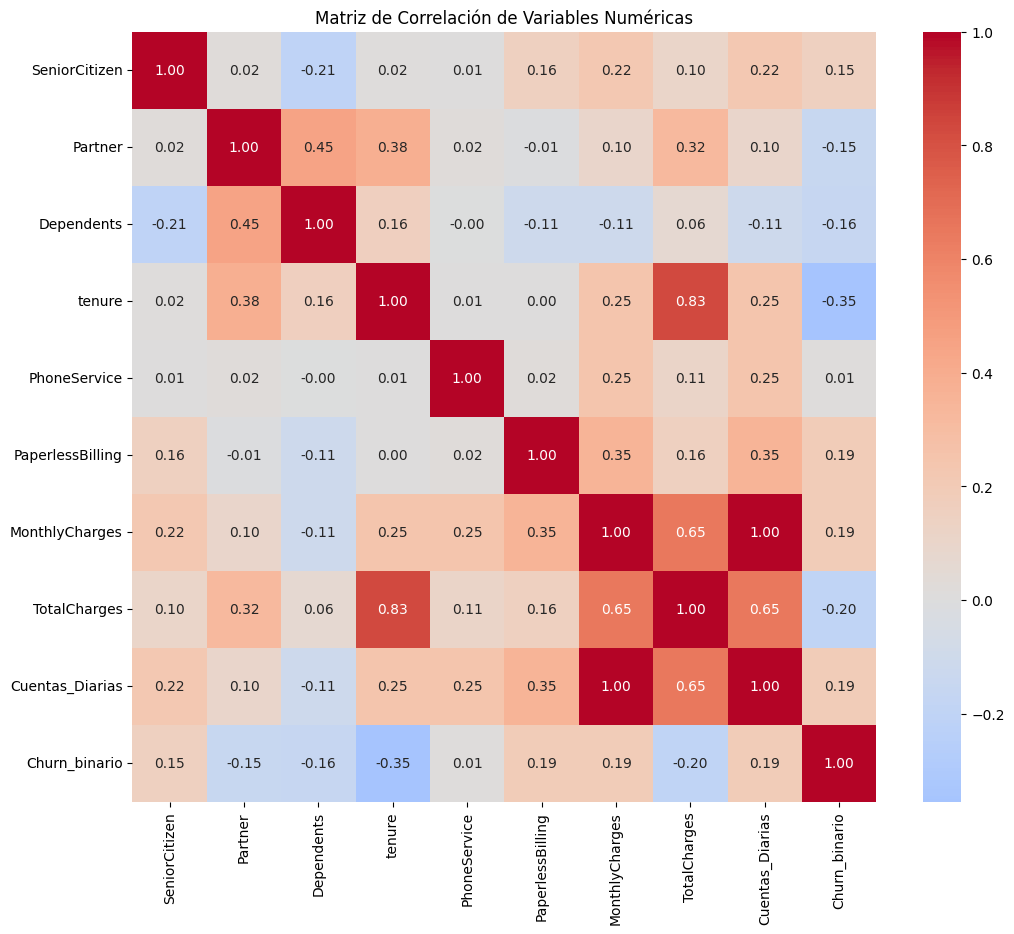

In [18]:
# Matriz de correlación
import seaborn as sns
import matplotlib.pyplot as plt

# Calcular matriz de correlación solo de variables numéricas + Churn_binario
numericas = df.select_dtypes(include=['int64', 'float64'])
corr = numericas.corr()

# Visualización
plt.figure(figsize=(12,10))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Matriz de Correlación de Variables Numéricas")
plt.show()

In [19]:
# Variables más correlacionadas con Churn
# Ordenar variables por correlación con Churn_binario
correlacion_churn = corr['Churn_binario'].sort_values(ascending=False)
print("Variables más correlacionadas con la cancelación:\n", correlacion_churn)

Variables más correlacionadas con la cancelación:
 Churn_binario       1.000000
Cuentas_Diarias     0.192914
MonthlyCharges      0.192858
PaperlessBilling    0.191454
SeniorCitizen       0.150541
PhoneService        0.011691
Partner            -0.149982
Dependents         -0.163128
TotalCharges       -0.199484
tenure             -0.354049
Name: Churn_binario, dtype: float64
